In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

survey_preferences = pd.read_csv("survey_preferences.csv")
brand_weights = pd.read_csv("brand_weights.csv")
brand_weights = brand_weights.set_index("Parameter")
brand_weights.index = brand_weights.index.str.strip()
car_ratings = pd.read_csv("car_ratings.csv")
car_ratings.columns = car_ratings.columns.str.strip()
car_ratings["Brand"] = car_ratings["Brand"].str.strip()

from IPython.display import display
display(survey_preferences)
display(brand_weights)
display(car_ratings)

,Parameter,Rating(out of 10)
0,Safety,8.5
1,Fuel Efficiency,8.0
2,Maintainability,7.5
3,Durability,7.5
4,Manoeuvrability,7.0
5,Cost,6.5
6,Aesthetics,6.5


,Tata,Maruti,Kia
Parameter,,,
Safety,16,15,13
Fuel Efficiency,8,9,8
Maintainability,11,10,7
Durability,10,9,8
Manoeuvrability,4,4,4
Cost,2,2,3
Aesthetics,1,1,1


,Car,Brand,Safety,Fuel Efficiency,Maintainability,Durability,Manoeuvrability,Cost,Aesthetics
0,Tata Nexon,Tata,9.0,7.0,8.0,7.50,7.0,7,7.5
1,Tata Altroz,Tata,8.5,8.0,7.5,8.00,8.0,8,8.0
2,Tata Tigor,Tata,7.0,7.5,7.0,7.00,7.5,8,6.5
3,Maruti Grand Vitara,Maruti,7.0,7.0,8.0,8.00,7.0,7,8.0
4,Maruti Breeza,Maruti,8.0,8.0,8.0,8.00,8.0,8,8.0
5,Maruti Ciaz,Maruti,6.0,9.0,9.0,9.00,8.0,8,7.0
6,Kia Sonet,Kia,7.0,7.5,8.0,8.00,8.0,8,7.5
7,Kia Carens,Kia,8.0,7.0,7.5,7.80,7.0,7,8.5
8,Kia Seltos,Kia,8.5,6.0,7.5,7.75,6.5,6,8.0


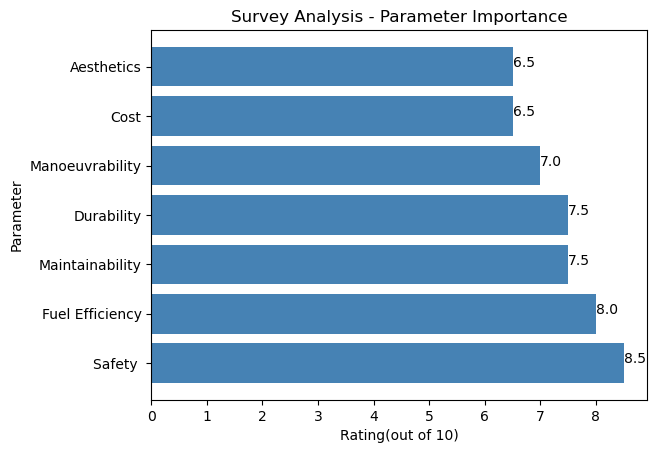

In [40]:
#Section 2 - Survey Analysis
#Visualizing how 47 respondents rated each parameter out of 10
#Using horizontal bar chart - parameters on Y axis, ratings on X axis

import matplotlib.pyplot as plt

survey_preferences = pd.read_csv("survey_preferences.csv")

parameter = survey_preferences["Parameter"]
rating = survey_preferences["Rating(out of 10)"]

#Plotting the bar chart
plt.xlabel("Rating(out of 10)")
plt.ylabel("Parameter")
plt.barh(parameter, rating, color='steelblue')
plt.title("Survey Analysis - Parameter Importance")

#add value labels to each bar
for index, value in enumerate(rating):
    plt.text(value, index, str(value))

plt.show()

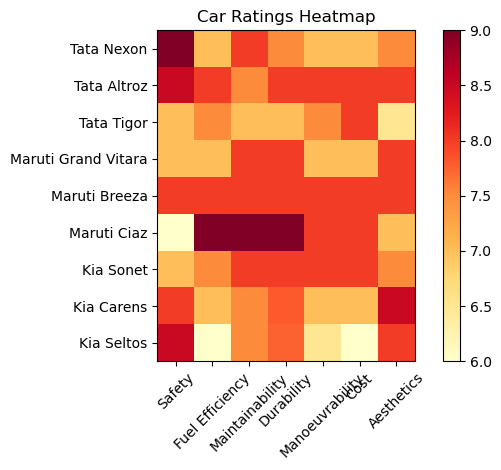

In [46]:
#Section 3 - Car Ratings Heatmap
#Dark red = high ratiing, Light Yellow = low rating

#Extract only numeric columns (drop Car and Brand)
numeric_data = car_ratings.select_dtypes(include = 'number')

#X axis - parameter names, Y axis - car names
plt.xticks(range(len(numeric_data.columns)), numeric_data.columns, rotation=45)
plt.yticks(range(len(car_ratings)), car_ratings["Car"])

#Plot the heatmap
plt.imshow( numeric_data, cmap = 'YlOrRd')

#Add colour scale on the side
plt.colorbar()

plt.title("Car Ratings Heatmap")
plt.tight_layout()
plt.show()

['Safety', 'Fuel Efficiency', 'Maintainability', 'Durability', 'Manoeuvrability', 'Cost', 'Aesthetics']
['Safety', 'Fuel Efficiency', 'Maintainability', 'Durability', 'Manoeuvrability', 'Cost', 'Aesthetics']


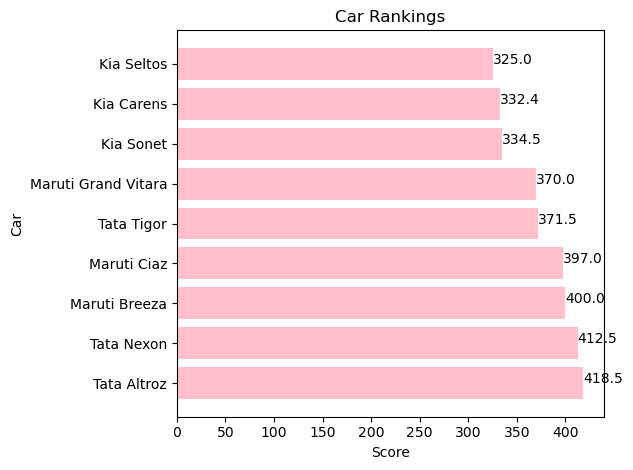

In [ ]:
# Section 4 - Weighted Scoring Model
### Calculating Final Scores for each car using brand weights


#Filter cars by brand
tata_cars = car_ratings[car_ratings["Brand"] == "Tata"]
weights1 = brand_weights["Tata"]
maruti_cars = car_ratings[car_ratings["Brand"] == "Maruti"]
weights2 = brand_weights["Maruti"]
kia_cars = car_ratings[car_ratings["Brand"] == "Kia"]
weights3 = brand_weights["Kia"]

#Select only numeric columns for each brand
tata_numeric = tata_cars.select_dtypes(include='number')
maruti_numeric = maruti_cars.select_dtypes(include='number')
kia_numeric = kia_cars.select_dtypes(include='number')

#Multiply car ratings by brand weights to get weighted scores
tata_scores = tata_numeric * weights1
maruti_scores = maruti_numeric * weights2
kia_scores = kia_numeric * weights3

#Sum across all parameters to get one final score per car
tata_final = tata_scores.sum(axis=1)
maruti_final = maruti_scores.sum(axis=1)
kia_final = kia_scores.sum(axis=1)

#Combine all brands into one result dataframe
result = pd.DataFrame({
    "Car" : pd.concat([tata_cars["Car"], maruti_cars["Car"], kia_cars["Car"]]), 
    "Score" : pd.concat([tata_final, maruti_final, kia_final])
})

#Sort by score and plot
results = result.sort_values("Score", ascending=False)
plt.barh(results["Car"], results["Score"], color = 'pink')
plt.xlabel("Score")
plt.ylabel("Car")
plt.title("Car Rankings")

#Sisplay score values at the end of each bar
for index, value in enumerate(results["Score"]):
    plt.text(value, index, str(round(value,1)))

print(tata_numeric.columns.tolist())
print(brand_weights.index.tolist())

plt.tight_layout()
plt.show()



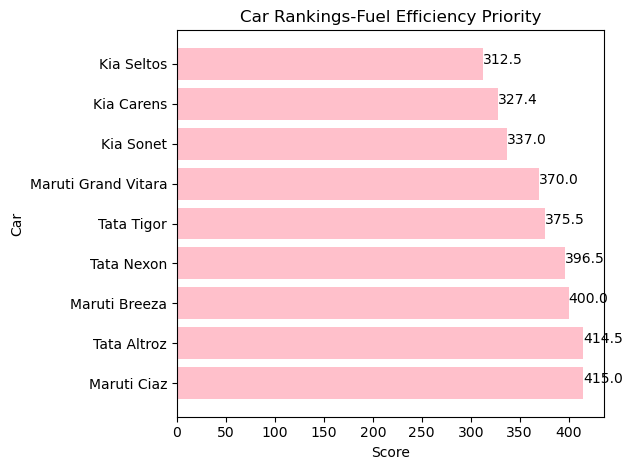

In [47]:
# Section 5 - Sensitivity Analysis
### WHat if Fuel Efficiency matters more than Safety??

new_weights = brand_weights.copy()

# Swap Safety and Fuel Efficiency weights
new_weights.loc["Safety"] = [8, 9, 8]
new_weights.loc["Fuel Efficiency"] = [16, 15, 13]

#Filter cars by brand
tata_cars = car_ratings[car_ratings["Brand"] == "Tata"]
new_weights1 = new_weights["Tata"]
maruti_cars = car_ratings[car_ratings["Brand"] == "Maruti"]
new_weights2 = new_weights["Maruti"]
kia_cars = car_ratings[car_ratings["Brand"] == "Kia"]
new_weights3 = new_weights["Kia"]

#Select only numeric columns for each brand
tata_numeric = tata_cars.select_dtypes(include='number')
maruti_numeric = maruti_cars.select_dtypes(include='number')
kia_numeric = kia_cars.select_dtypes(include='number')

#Multiply car ratings by brand weights to get weighted scores
tata_scores = tata_numeric * new_weights1
maruti_scores = maruti_numeric * new_weights2
kia_scores = kia_numeric * new_weights3

#Sum across all parameters to get one final score per car
tata_final = tata_scores.sum(axis=1)
maruti_final = maruti_scores.sum(axis=1)
kia_final = kia_scores.sum(axis=1)

#Combine all brands into one result dataframe
result = pd.DataFrame({
    "Car" : pd.concat([tata_cars["Car"], maruti_cars["Car"], kia_cars["Car"]]), 
    "Score" : pd.concat([tata_final, maruti_final, kia_final])
})

#Sort by score and plot
results = result.sort_values("Score", ascending=False)
plt.barh(results["Car"], results["Score"], color = 'pink')
plt.xlabel("Score")
plt.ylabel("Car")
plt.title("Car Rankings-Fuel Efficiency Priority")

#Sisplay score values at the end of each bar
for index, value in enumerate(results["Score"]):
    plt.text(value, index, str(round(value,1)))

plt.tight_layout()
plt.show()

